# Compare detector models (multilingual) for viral-worthiness

Fine-tunes several encoders on the **binary detector** task (`viral_label`:
top-quartile vs bottom-quartile in-category engagement) and compares them on the
held-out test set.

Why multilingual: this trending data is global — **~58% of titles contain
non-ASCII text and ~12% have no Latin letters at all** (Cyrillic, Vietnamese,
Khmer, …). An English-only, *uncased* model like `distilbert-base-uncased`
mangles those and discards casing (ALL-CAPS is a virality cue), so we expect
**cased multilingual** models to win here. The English model is included only as
a baseline to show the gap.

| Model | Type |
|-------|------|
| `distilbert-base-uncased` | English baseline (uncased) |
| `distilbert-base-multilingual-cased` | distilled, multilingual, cased |
| `bert-base-multilingual-cased` | mBERT |
| `microsoft/Multilingual-MiniLM-L12-H384` | small + multilingual |
| `xlm-roberta-base` | strongest multilingual encoder |

In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers", "torch", "datasets", "accelerate",
                "scikit-learn", "scipy", "pandas", "matplotlib",
                "sentencepiece", "protobuf"], check=True)

CompletedProcess(args=['/Users/angie/miniforge3/envs/sam2env/bin/python', '-m', 'pip', 'install', '-q', 'transformers', 'torch', 'datasets', 'accelerate', 'scikit-learn', 'scipy', 'pandas', 'matplotlib', 'sentencepiece', 'protobuf'], returncode=0)

## Config

In [2]:
import os

# Lift PyTorch's MPS memory ceiling to avoid hard "out of memory" aborts.
# Must be set before torch is imported (next cell).
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")

def _find(name):
    for p in [name, os.path.join("youtube_title_trending", name)]:
        if os.path.exists(p):
            return p
    return name
PROC_DIR = os.path.dirname(_find(os.path.join("processed", "train.parquet")))

# Multilingual detectors to compare.
MODELS = [
    "distilbert-base-multilingual-cased",       # distilled, multilingual, cased
    "bert-base-multilingual-cased",             # mBERT
    "microsoft/Multilingual-MiniLM-L12-H384",   # small + multilingual
]

MAX_LEN    = 64
EPOCHS     = 3
BATCH_SIZE = 8       # lowered for MPS memory; drop to 4 if you still hit OOM
GRAD_ACCUM = 2       # effective batch = BATCH_SIZE * GRAD_ACCUM = 16
LR         = 2e-5
LIMIT_TRAIN = None   # set an int for a quick smaller run
print("data dir:", PROC_DIR)

data dir: processed


In [3]:
import gc, time
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, TrainingArguments, Trainer)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.special import softmax

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", DEVICE)

def load_detector_split(name):
    df = pd.read_parquet(os.path.join(PROC_DIR, f"{name}.parquet")).dropna(subset=["viral_label"]).copy()
    df["viral_label"] = df["viral_label"].astype(int)
    return df

train_df, val_df, test_df = load_detector_split("train"), load_detector_split("val"), load_detector_split("test")
if LIMIT_TRAIN:
    train_df = train_df.head(LIMIT_TRAIN)
print(f"detector rows -> train {len(train_df)} | val {len(val_df)} | test {len(test_df)}")

/Users/angie/miniforge3/envs/sam2env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
detector rows -> train 3674 | val 472 | test 434


## Train + evaluate one model

In [4]:
def cls_metrics(eval_pred):
    logits, labels = eval_pred
    probs = softmax(logits, axis=1)[:, 1]
    preds = logits.argmax(-1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1": f1_score(labels, preds),
            "auc": roc_auc_score(labels, probs)}

def make_ds(df, tok):
    d = Dataset.from_pandas(df[["video_title", "viral_label"]]
                            .rename(columns={"video_title": "text", "viral_label": "labels"}),
                            preserve_index=False)
    return d.map(lambda b: tok(b["text"], truncation=True, max_length=MAX_LEN),
                 batched=True, remove_columns=["text"])

def train_and_eval(model_name):
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    args = TrainingArguments(
        output_dir=f"models/cmp/{model_name.replace('/', '_')}",
        num_train_epochs=EPOCHS, per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE, gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR, weight_decay=0.01,
        eval_strategy="epoch", save_strategy="no", logging_steps=100, report_to="none")
    trainer = Trainer(model=model, args=args,
                      train_dataset=make_ds(train_df, tok), eval_dataset=make_ds(val_df, tok),
                      data_collator=DataCollatorWithPadding(tok), processing_class=tok,
                      compute_metrics=cls_metrics)
    t0 = time.time()
    trainer.train()
    train_sec = time.time() - t0
    test_metrics = trainer.evaluate(make_ds(test_df, tok))
    result = {"model": model_name,
              "params_M": round(sum(p.numel() for p in model.parameters()) / 1e6),
              "auc": round(test_metrics["eval_auc"], 4),
              "f1": round(test_metrics["eval_f1"], 4),
              "accuracy": round(test_metrics["eval_accuracy"], 4),
              "train_sec": round(train_sec)}
    del model, trainer
    gc.collect()
    if DEVICE == "mps":
        torch.mps.empty_cache()
    return result

## Run the comparison

Trains every model in `MODELS` (slow cell). First run downloads each checkpoint.

In [5]:
results = []
for name in MODELS:
    print(f"=== {name} ===")
    results.append(train_and_eval(name))
    print("  ", results[-1])

=== distilbert-base-multilingual-cased ===


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 17825.35it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 472/472 [00:00<00:00, 68763.86 examples/s]
/Users/angie/miniforge3/envs/sam2env/lib/python3.11/site-packages/torch/u

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,1.037851,0.523592,0.762712,0.757576,0.835358
2,0.775530,0.505522,0.779661,0.791165,0.851516
3,0.554951,0.534790,0.788136,0.792531,0.858174


/Users/angie/miniforge3/envs/sam2env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/angie/miniforge3/envs/sam2env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Map: 100%|██████████| 434/434 [00:00<00:00, 25833.45 examples/s]
/Users/angie/miniforge3/envs/sam2env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1,Auc
0.554951,0.418984,3,0.829493,0.832579,0.895589


...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 58924.57it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: microsoft/Multilingual-MiniLM-L12-H384
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 472/472 [00:00<00:00, 67484.03 examples/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.
/Users/angie/miniforge3/envs/sam2env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,1.112845,0.541450,0.739407,0.745342,0.823536
2,0.927669,0.521124,0.766949,0.759825,0.847323
3,0.828462,0.501879,0.775424,0.780992,0.852020


/Users/angie/miniforge3/envs/sam2env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/angie/miniforge3/envs/sam2env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Map: 100%|██████████| 434/434 [00:00<00:00, 35104.19 examples/s]
/Users/angie/miniforge3/envs/sam2env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1,Auc
0.828462,0.431328,3,0.815668,0.816514,0.898287


   {'model': 'microsoft/Multilingual-MiniLM-L12-H384', 'params_M': 118, 'auc': 0.8983, 'f1': 0.8165, 'accuracy': 0.8157, 'train_sec': 133}


## Results

In [6]:
table = pd.DataFrame(results).sort_values("auc", ascending=False).reset_index(drop=True)
table

,model,params_M,auc,f1,accuracy,train_sec
0,microsoft/Multilingual-MiniLM-L12-H384,118,0.8983,0.8165,0.8157,133
1,distilbert-base-multilingual-cased,135,0.8956,0.8326,0.8295,136
2,bert-base-multilingual-cased,178,0.8880,0.7926,0.7926,191


Matplotlib is building the font cache; this may take a moment.


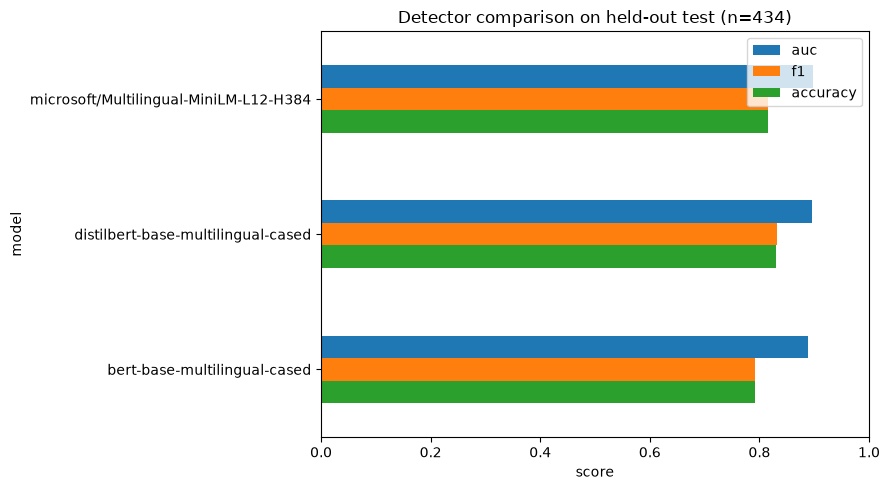

In [7]:
import matplotlib.pyplot as plt

ax = table.set_index("model")[["auc", "f1", "accuracy"]].plot(kind="barh", figsize=(9, 5))
ax.set_title(f"Detector comparison on held-out test (n={len(test_df)})")
ax.set_xlabel("score"); ax.set_xlim(0, 1)
ax.invert_yaxis()
plt.tight_layout(); plt.show()